In [1]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

import seaborn as sns
import sys
import os
import pandas as pd
import shap
import sys
import os

/mnt/Disco2/Projects/dc_model_ts/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
sys.path.insert(0, os.path.abspath(".."))
from src.pipeline import run_etl
from src.modeling import seed, scoring, train_model

In [11]:
df_tabla_0_imp, df_tabla_1_imp, df_mean, df_median = run_etl("./../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

 Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida       

In [12]:
X_mean = df_mean.drop(columns=['dc'])
y_mean = df_mean['dc']

X_median = df_median.drop(columns=['dc'])
y_median = df_median['dc']

In [ ]:
#Variables predictoras y variable objetivo
features = df_mean.drop(columns=['dc'])

#Diccionario de modelos a entrenar
models = {
    "Logistic Regression":
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=seed
        ),

    "Random Forest":
        RandomForestClassifier(
            class_weight="balanced",
            n_estimators=200,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            max_depth=3,
            random_state=seed
        ),

    "SVM Linear":
        SVC(
            kernel="linear",
            probability=True,
            class_weight="balanced",
            random_state=seed
        ),

    "SVM RBF":
        SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=seed
        ),
    "KNeighborsClassifier": 
        KNeighborsClassifier(
            n_neighbors=9,
            weights='uniform',
            metric='manhattan',
            n_jobs=-1
        ),
    "GradientBoostingClassifier": GradientBoostingClassifier(
            n_estimators=30,
            learning_rate=0.05,
            max_depth=1,
            subsample=0.8,
            random_state=seed
        )
}

# Se filtran las filas que tengan etiquetas validas (0, 1, 2)
mask = y != -1
X = X[mask]
y = y[mask]


# Se establecen las métricas de evaluación más acordes, teniendo en cuenta que el dataset es pequeño y las clases estan desbalanceadas.
scoring = ['f1_macro', 'balanced_accuracy', 'matthews_corrcoef']


In [6]:
# Configuración de la validación cruzada estratificada repetida / debido a la naturaleza desbalanceada de las clases
cv_repeated_kfold = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=seed
)
#Configuración de la validación cruzada estratificada / debido a la naturaleza desbalanceada de las clases
cv_kfold= StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

In [15]:
# Resultados
results = []
results_overfitting = []

for name, model in models.items():
    
    # Se crea un pipeline que incluye imputación, aunque el conjunto de datos ya esta preprocesado, es una buena práctica para evitar problemas con NaNs en otros conjuntos de datos.
    # 1: Rellenar NaNs con la mediana (SimpleImputer)
    # 2: Escalar los datos a Media=0, Std=1 (StandardScaler)
    # 3: Entrenar el clasificador
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    
    # Validación cruzada con las métricas definidas
    cv_scores = cross_validate(pipeline, X_mean, y_mean, cv=cv_repeated_kfold, scoring=scoring, return_train_score=True)

    # medias para calcular la brecha entre entrenamiento y validación/test, para detectar sobreentrenamiento
    train_f1 = cv_scores['train_f1_macro'].mean()
    test_f1 = cv_scores['test_f1_macro'].mean()
    
    results_overfitting.append({
        "Modelo": name,
        "F1 (Entrenamiento)": train_f1,
        "F1 (Validación / Test)": test_f1,
        # Si la brecha es muy grande (> 0.15), hay sobreentrenamiento
        "Brecha (Caída)": train_f1 - test_f1,
        "F1 Validación (Std)": cv_scores['test_f1_macro'].std()
    })
    
    # Calcular y almacenar las medias y desviaciones estándar
    results.append({
        "Modelo": name,
        "F1-Score Macro": test_f1,
        "F1-Score (Std)": cv_scores['test_f1_macro'].std(),
        "Balanced Accuracy": cv_scores['test_balanced_accuracy'].mean(),
        "Bal. Acc. (Std)": cv_scores['test_balanced_accuracy'].std(),
        "Matthews Corr. Coef": cv_scores['test_matthews_corrcoef'].mean(),
        "MCC (Std)": cv_scores['test_matthews_corrcoef'].std()
    })

# Resultados, ordenados de mejor a peor
df_results = pd.DataFrame(results).sort_values(by="F1-Score Macro", ascending=False)
print("Resultados de los modelos")
print("-" * 70)
display(df_results.round(4))

# Resultados del overfitting
df_overfit = pd.DataFrame(results_overfitting).sort_values(by="F1 (Validación / Test)", ascending=False)
print("Analisis de overfitting")
print("-" * 85)
display(df_overfit.round(4))

Resultados de los modelos
----------------------------------------------------------------------


,Modelo,F1-Score Macro,F1-Score (Std),Balanced Accuracy,Bal. Acc. (Std),Matthews Corr. Coef,MCC (Std)
3,SVM RBF,0.7514,0.0851,0.7574,0.0877,0.6145,0.1299
2,SVM Linear,0.7480,0.0847,0.7598,0.0883,0.6104,0.1361
0,Logistic Regression,0.7438,0.0835,0.7591,0.0843,0.6055,0.1298
1,Random Forest,0.7388,0.0824,0.7702,0.0813,0.6103,0.1261
4,KNeighborsClassifier,0.6485,0.1081,0.6446,0.1080,0.4754,0.1629
5,GradientBoostingClassifier,0.6275,0.1103,0.6156,0.1013,0.4597,0.1604


Analisis de overfitting
-------------------------------------------------------------------------------------


,Modelo,F1 (Entrenamiento),F1 (Validación / Test),Brecha (Caída),F1 Validación (Std)
3,SVM RBF,0.8912,0.7514,0.1398,0.0851
2,SVM Linear,0.8960,0.7480,0.1481,0.0847
0,Logistic Regression,0.8934,0.7438,0.1496,0.0835
1,Random Forest,0.8558,0.7388,0.1169,0.0824
4,KNeighborsClassifier,0.7540,0.6485,0.1054,0.1081
5,GradientBoostingClassifier,0.7726,0.6275,0.1451,0.1103


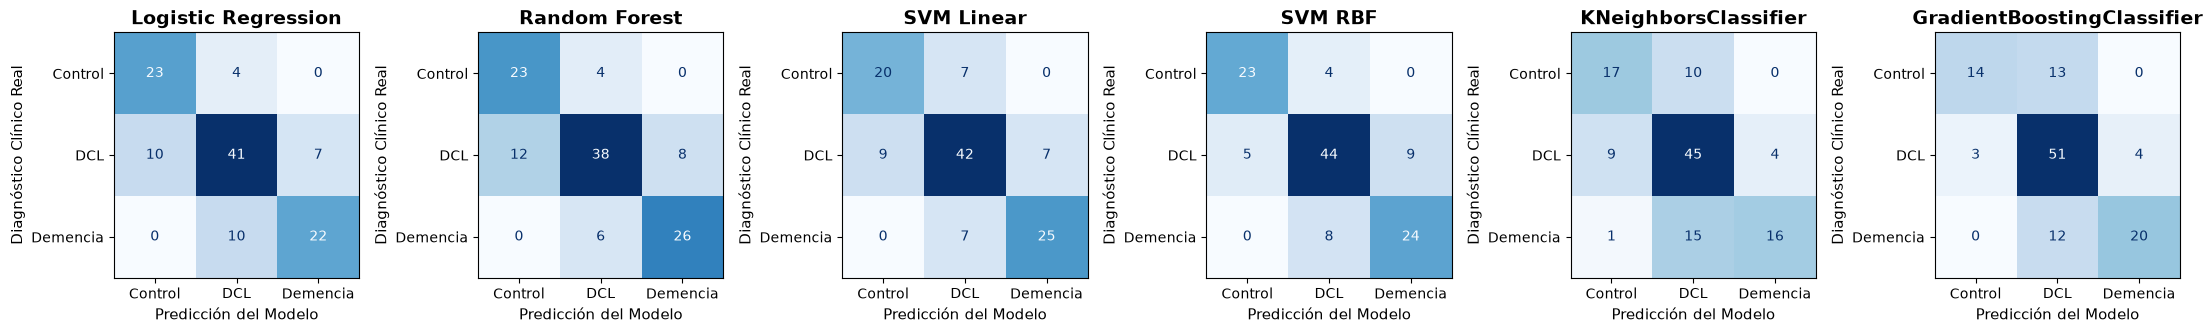

In [19]:
fig, axes = plt.subplots(1, len(models), figsize=(22, 5))

for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    #Se generan de nuevo las predicciones para todo el dataset, pero cada paciente es evaluado solo cuando su fold fue el "fold de prueba".
    
    y_pred = cross_val_predict(pipeline, X_mean, y_mean, cv=cv_kfold)
    
    # Calculo de la matriz de confusión y visualización
    cm = confusion_matrix(y, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "DCL", "Demencia"])

    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}", fontweight="bold", fontsize=14)
    ax.set_xlabel("Predicción del Modelo", fontsize=11)
    ax.set_ylabel("Diagnóstico Clínico Real", fontsize=11)

plt.tight_layout()
plt.show()


In [16]:
# Resultados
results = []
results_overfitting = []

for name, model in models.items():
    
    # Se crea un pipeline que incluye imputación, aunque el conjunto de datos ya esta preprocesado, es una buena práctica para evitar problemas con NaNs en otros conjuntos de datos.
    # 1: Rellenar NaNs con la mediana (SimpleImputer)
    # 2: Escalar los datos a Media=0, Std=1 (StandardScaler)
    # 3: Entrenar el clasificador
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    
    # Validación cruzada con las métricas definidas
    cv_scores = cross_validate(pipeline, X_median, y_median, cv=cv_repeated_kfold, scoring=scoring, return_train_score=True)

    # medias para calcular la brecha entre entrenamiento y validación/test, para detectar sobreentrenamiento
    train_f1 = cv_scores['train_f1_macro'].mean()
    test_f1 = cv_scores['test_f1_macro'].mean()
    
    results_overfitting.append({
        "Modelo": name,
        "F1 (Entrenamiento)": train_f1,
        "F1 (Validación / Test)": test_f1,
        # Si la brecha es muy grande (> 0.15), hay sobreentrenamiento
        "Brecha (Caída)": train_f1 - test_f1,
        "F1 Validación (Std)": cv_scores['test_f1_macro'].std()
    })
    
    # Calcular y almacenar las medias y desviaciones estándar
    results.append({
        "Modelo": name,
        "F1-Score Macro": test_f1,
        "F1-Score (Std)": cv_scores['test_f1_macro'].std(),
        "Balanced Accuracy": cv_scores['test_balanced_accuracy'].mean(),
        "Bal. Acc. (Std)": cv_scores['test_balanced_accuracy'].std(),
        "Matthews Corr. Coef": cv_scores['test_matthews_corrcoef'].mean(),
        "MCC (Std)": cv_scores['test_matthews_corrcoef'].std()
    })

# Resultados, ordenados de mejor a peor
df_results = pd.DataFrame(results).sort_values(by="F1-Score Macro", ascending=False)
print("Resultados de los modelos")
print("-" * 70)
display(df_results.round(4))

# Resultados del overfitting
df_overfit = pd.DataFrame(results_overfitting).sort_values(by="F1 (Validación / Test)", ascending=False)
print("Analisis de overfitting")
print("-" * 85)
display(df_overfit.round(4))

Resultados de los modelos
----------------------------------------------------------------------


,Modelo,F1-Score Macro,F1-Score (Std),Balanced Accuracy,Bal. Acc. (Std),Matthews Corr. Coef,MCC (Std)
0,Logistic Regression,0.6914,0.0902,0.7065,0.0942,0.5183,0.1450
2,SVM Linear,0.6647,0.0866,0.6835,0.0856,0.4801,0.1360
3,SVM RBF,0.6613,0.1014,0.6720,0.1037,0.4775,0.1589
1,Random Forest,0.6407,0.0961,0.6782,0.0980,0.4671,0.1455
4,KNeighborsClassifier,0.6076,0.1057,0.6003,0.0992,0.4341,0.1534
5,GradientBoostingClassifier,0.5874,0.1082,0.5812,0.0954,0.4132,0.1628


Analisis de overfitting
-------------------------------------------------------------------------------------


,Modelo,F1 (Entrenamiento),F1 (Validación / Test),Brecha (Caída),F1 Validación (Std)
0,Logistic Regression,0.8569,0.6914,0.1655,0.0902
2,SVM Linear,0.8455,0.6647,0.1808,0.0866
3,SVM RBF,0.8688,0.6613,0.2075,0.1014
1,Random Forest,0.7588,0.6407,0.1180,0.0961
4,KNeighborsClassifier,0.6659,0.6076,0.0583,0.1057
5,GradientBoostingClassifier,0.7224,0.5874,0.1350,0.1082


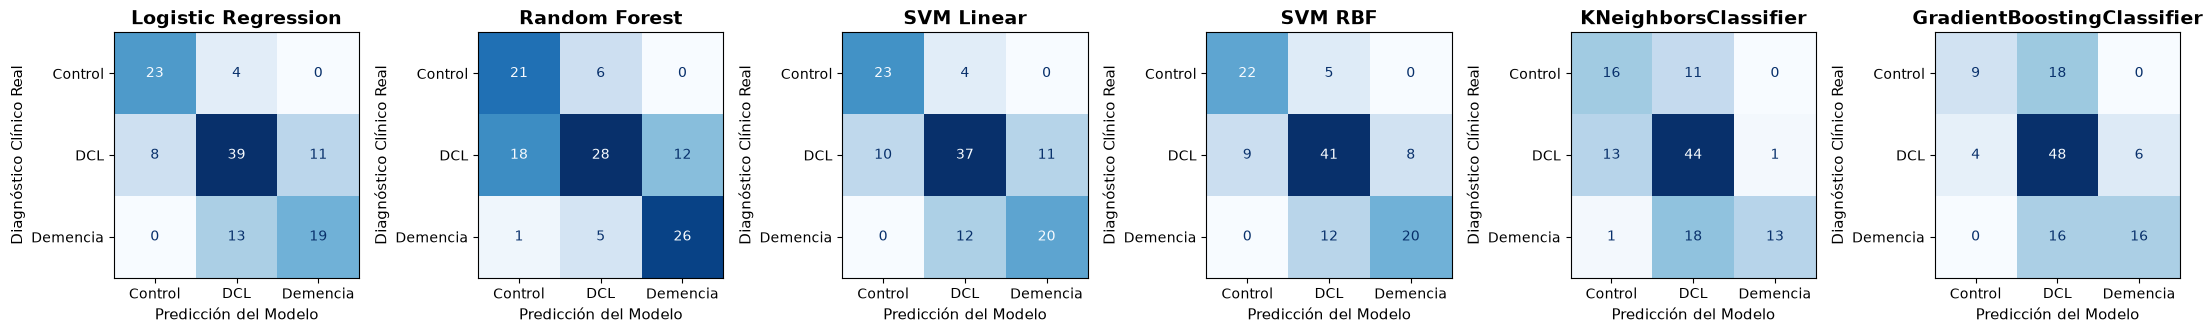

In [20]:
fig, axes = plt.subplots(1, len(models), figsize=(22, 5))

for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    #Se generan de nuevo las predicciones para todo el dataset, pero cada paciente es evaluado solo cuando su fold fue el "fold de prueba".
    
    y_pred = cross_val_predict(pipeline, X_median, y_median, cv=cv_kfold)
    
    # Calculo de la matriz de confusión y visualización
    cm = confusion_matrix(y, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "DCL", "Demencia"])

    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}", fontweight="bold", fontsize=14)
    ax.set_xlabel("Predicción del Modelo", fontsize=11)
    ax.set_ylabel("Diagnóstico Clínico Real", fontsize=11)

plt.tight_layout()
plt.show()


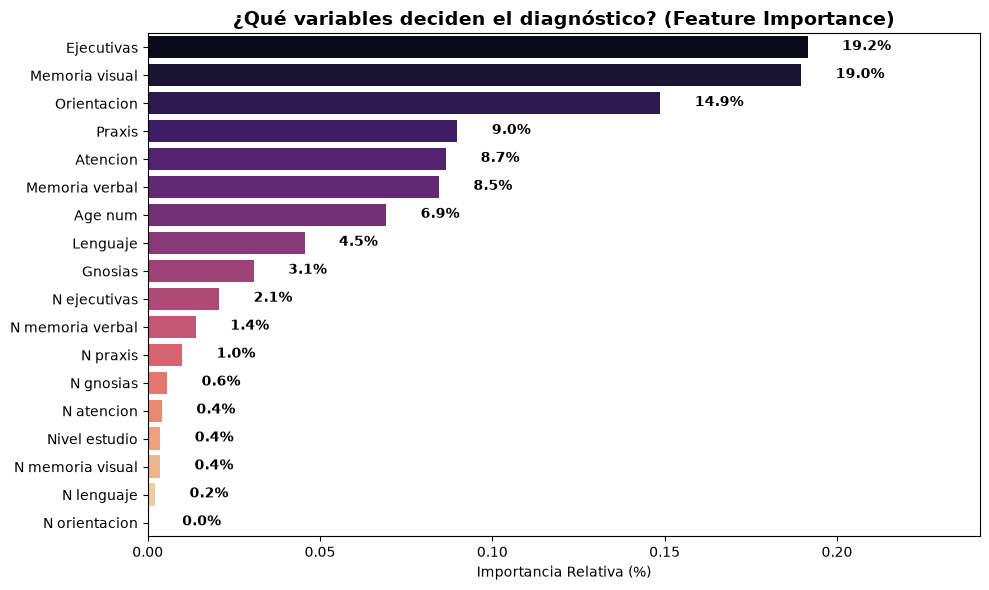

In [21]:

# Importancia global de las variables (Feature Importance) usando Random Forest
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('classifier', models["Random Forest"])
])

rf_pipeline.fit(X, y)

# Se extrae la importancia de las variables del modelo Random Forest entrenado
importancias = rf_pipeline.named_steps['classifier'].feature_importances_

# Se crea un dataframe ordenado con las importancias y los nombres de las variables
df_imp = pd.DataFrame({
    'Variable': X_mean.columns.str.capitalize().str.replace("_", " "),
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_imp, x='Importancia', y='Variable', palette="magma", ax=ax)

ax.set_title("¿Qué variables deciden el diagnóstico? (Feature Importance)", fontweight="bold", fontsize=14)
ax.set_xlabel("Importancia Relativa (%)")
ax.set_ylabel("")

# Se añade el porcentaje en texto al lado de cada barra
for i, v in enumerate(df_imp['Importancia']):
    ax.text(v + 0.01, i + 0.1, f"{v*100:.1f}%", color='black', fontweight='bold')

plt.xlim(0, max(importancias) + 0.05) 
plt.tight_layout()
plt.show()


In [24]:
# Predicción con un paciente de ejemplo (fila 5 del dataset)
paciente_ejemplo = X_mean.iloc[[5]]

# Usamos predict_proba en lugar de predict
probabilidades = rf_pipeline.predict_proba(paciente_ejemplo)[0]

print(f"Probabilidad de ser Control Sano {probabilidades[0]*100:.1f}%")
print(f"Probabilidad de tener DCL {probabilidades[1]*100:.1f}%")
print(f"Probabilidad de tener Demencia {probabilidades[2]*100:.1f}%")


Probabilidad de ser Control Sano 14.4%
Probabilidad de tener DCL 65.7%
Probabilidad de tener Demencia 19.9%


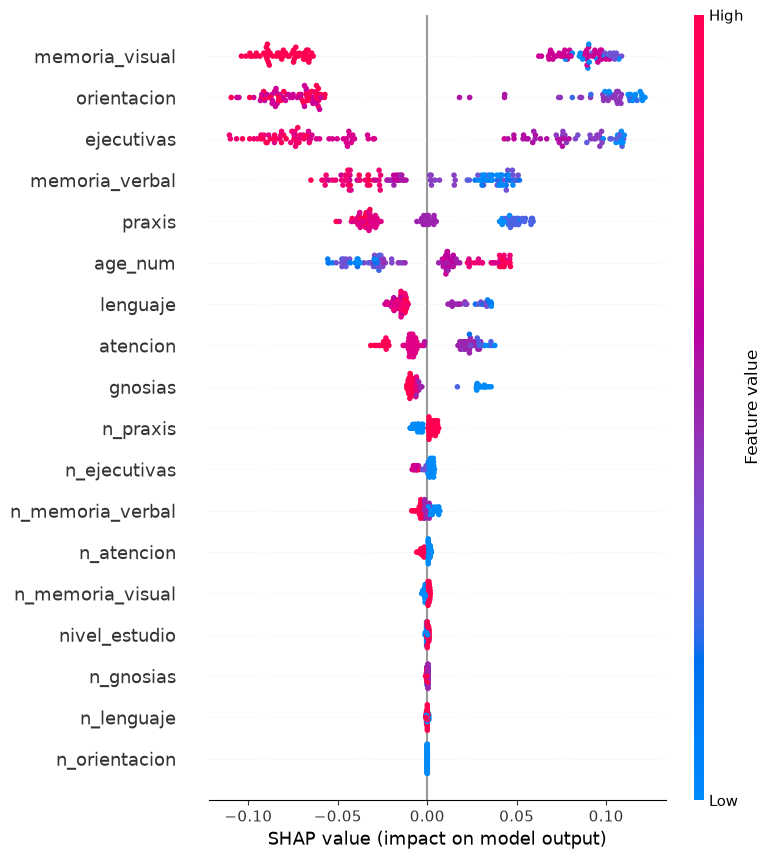

In [25]:
#Shap con javascript
shap.initjs()

# Random forest entrenado y datos limpios
rf_model = rf_pipeline.named_steps['classifier']
imputer = rf_pipeline.named_steps['imputer']
X_limpio = imputer.transform(X_mean)

# Se crea el objeto explainer de SHAP para el modelo Random Forest entrenado y los datos limpios
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_limpio)

#Solución al error de dimensiones en SHAP
# Verificación de cómo estructuró SHAP los datos (Lista vs Matriz 3D)
if isinstance(shap_values, list):
    # Versión antigua. Lista. El índice 2 corresponde a la clase 'Demencia'
    shap_demencia = shap_values[2]
else:
    # Nueva versión. cubo 3D [pacientes, variables, clases]
    # Se corta el cubo para extraer solo la rebanada de la clase 2 ('Demencia')
    shap_demencia = shap_values[:, :, 2]

# Se gráfica el resumen de SHAP para la clase 'Demencia', mostrando el impacto de cada variable en la predicción del modelo.
shap.summary_plot(shap_demencia, X_limpio, feature_names=X.columns, title="Impacto de Variables para diagnosticar Demencia")


In [ ]:
def apply_grid_search(pipeline, parametros, X, y, cv):
    """
    Función para aplicar GridSearchCV a un pipeline de scikit-learn.
    
    Args:
        pipeline: Pipeline de scikit-learn que contiene el modelo y los pasos de preprocesamiento.
        parametros: Diccionario con los parámetros a buscar en el GridSearchCV.
        X: Características predictoras.
        y: Variable objetivo.
        cv: Estrategia de validación cruzada.
    Returns:
        best_model: El mejor modelo encontrado por GridSearchCV.
        best_params: Los mejores parámetros encontrados.
    """

    grid_search = GridSearchCV(pipeline, parametros, cv=cv, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(X, y)
    
    
    return grid_search

In [28]:
# Busqueda de hiperparámetros para SVM lineal
#--------------------------------------------------------------------------------------------
print("Afinando Support Vector Machine (Lineal)")
pipeline_svm_linear = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),                 
    ('classifier', SVC(kernel='linear', class_weight='balanced', random_state=seed))
])

# Parámetro 'C': C bajos = modelo más simple/general. C altos = modelo muy complejo/ajustado
parametros_svm = {
    'classifier__C': [0.01, 0.1, 1, 10, 50],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'classifier__class_weight': ['balanced']
}

grid_svm_mean = applyGrid(pipeline_svm_linear, parametros_svm, X_mean, y_mean, cv_repeated_kfold)
print(f"Mejor 'C' para SVM para la media: {grid_svm_mean.best_params_}")
print(f"F1-Score Máximo para la media: {grid_svm_mean.best_score_:.4f}\n")

grid_svm_median = applyGrid(pipeline_svm_linear, parametros_svm, X_median, y_median, cv_repeated_kfold)
print(f"Mejor 'C' para SVM para la media: {grid_svm_median.best_params_}")
print(f"F1-Score Máximo para la media: {grid_svm_median.best_score_:.4f}\n")


# Random Forest afinado con GridSearchCV
#--------------------------------------------------------------------------------------------
print("Afinando Random Forest")
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),                
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=seed))
])

# max_depth: Profundidad. n_estimators: Cantidad de árboles.
parametros_rf = {
    'classifier__max_depth': [2, 3, 4], 
    'classifier__n_estimators': [50, 100, 200],
    'classifier__min_samples_leaf': [1, 2, 5], # Se detiene si no quedan suficientes pacientes en una hoja del árbol, evitando sobreajuste
    'classifier__min_samples_split': [2, 5, 10]
}

grid_rf_mean = applyGrid(pipeline_rf, parametros_rf, X_mean, y_mean, cv_repeated_kfold)
print(f"Mejores parámetros para RF: {grid_rf_mean.best_params_}")
print(f"F1-Score Máximo: {grid_rf_mean.best_score_:.4f}")


grid_rf_median = applyGrid(pipeline_rf, parametros_rf, X_median, y_median, cv_repeated_kfold)
print(f"Mejores parámetros para RF: {grid_rf_median.best_params_}")
print(f"F1-Score Máximo: {grid_rf_median.best_score_:.4f}")

Afinando Support Vector Machine (Lineal)
Mejor 'C' para SVM para la media: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale'}
F1-Score Máximo para la media: 0.7904

Mejor 'C' para SVM para la media: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale'}
F1-Score Máximo para la media: 0.6989

Afinando Random Forest
Mejores parámetros para RF: {'classifier__max_depth': 4, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
F1-Score Máximo: 0.7782
Mejores parámetros para RF: {'classifier__max_depth': 4, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
F1-Score Máximo: 0.6636


In [29]:
# SVM RBF 
#--------------------------------------------------------------------------------------------
print("Afinando Support Vector Machine (RBF)")
pipline_svm_rbf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=seed))
])


svm_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 50],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'classifier__class_weight': ['balanced']
}

grid_svm_rbf_mean = applyGrid(pipline_svm_rbf, svm_param_grid, X_mean, y_mean, cv_repeated_kfold)
print(f"Mejores parámetros para SVM RBF: {grid_svm_rbf_mean.best_params_}")
print(f"F1-Score Máximo: {grid_svm_rbf_mean.best_score_:.4f}")

grid_svm_rbf_median = applyGrid(pipline_svm_rbf, svm_param_grid, X_median, y_median, cv_repeated_kfold)
print(f"Mejores parámetros para SVM RBF: {grid_svm_rbf_median.best_params_}")
print(f"F1-Score Máximo: {grid_svm_rbf_median.best_score_:.4f}")


#GradientBoostingClassifier
#--------------------------------------------------------------------------------------------
print("Afinando Gradient Boosting")
pipeline_gb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', GradientBoostingClassifier(random_state=seed))
])

gb_param_grid = {
    'classifier__n_estimators': [50, 80, 100],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2, 3],
    'classifier__min_samples_leaf': [5, 8, 10],
    'classifier__subsample': [0.7, 0.8],
    'classifier__max_features': ['sqrt']
}

grid_gb_mean = applyGrid(pipeline_gb, gb_param_grid, X_mean, y_mean, cv_repeated_kfold)
print(f"Mejores parámetros para Gradient Boosting: {grid_gb_mean.best_params_}")
print(f"F1-Score Máximo: {grid_gb_mean.best_score_:.4f}")

grid_gb_median = applyGrid(pipeline_gb, gb_param_grid, X_median, y_median, cv_repeated_kfold)
print(f"Mejores parámetros para Gradient Boosting: {grid_gb_median.best_params_}")
print(f"F1-Score Máximo: {grid_gb_median.best_score_:.4f}")

Afinando Support Vector Machine (RBF)
Mejores parámetros para SVM RBF: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.01}
F1-Score Máximo: 0.7599
Mejores parámetros para SVM RBF: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.01}
F1-Score Máximo: 0.6697
Afinando Gradient Boosting
Mejores parámetros para Gradient Boosting: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 100, 'classifier__subsample': 0.7}
F1-Score Máximo: 0.7650
Mejores parámetros para Gradient Boosting: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 50, 'classifier__subsample': 0.7}
F1-Score Máximo: 0.6856
